# 8. Componente espacial (sección 2.7)

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

Obligatorio porque el dataset tiene latitud/longitud. Cubre: validación de
coordenadas, mapas, patrón de puntos y cobertura, autocorrelación espacial
(Moran global, LISA, Getis-Ord Gi*, correlograma/semivariograma),
heterogeneidad espacial, distancias, efecto de escala (MAUP), ingeniería de
características espaciales y consecuencias para el modelado.

Todo con **train**. Implementación propia con numpy/scipy/scikit-learn en
`src/espacial.py` (sin geopandas/pysal, para no depender de librerías
geoespaciales pesadas cuya instalación varía según la versión de Python);
las fórmulas son las estándar (Moran 1950; Anselin 1995; Getis & Ord 1992;
Clark & Evans 1954; Ripley 1976).

In [1]:
# Preparación del capítulo: rutas, librerías y módulos propios de src/. Se carga
# SOLO la partición de entrenamiento: todo el EDA espacial se hace sin mirar test
# para que ninguna decisión (p. ej. el tamaño del buffer) quede contaminada por él.
import sys
import warnings
from pathlib import Path

# El libro puede ejecutarse desde notebooks/ o desde la raíz; en ambos casos se
# agrega la raíz al path para poder importar el paquete src.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
# Solo se silencian avisos de deprecación de pandas/seaborn (no afectan resultados).
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Módulos propios: configuración (C), espacial (S: Moran, LISA, Gi*, Ripley...),
# estadística (E: ajustes de p-valores), gráficos (G), limpieza (L), partición (P).
from src import config as C
from src import espacial as S
from src import estadistica as E
from src import graficos as G
from src import limpieza as L
from src import particion as P

G.estilo()  # estilo común de figuras (fuentes grandes para el libro)
C.aviso_sintetico()  # advierte si se está usando el CSV sintético de pruebas
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
# Dataset ya limpio y particionado (cap. 2); solo filas con particion == "train".
train = P.cargar_particion(solo="train")
print(f"Train: {len(train):,} filas")

Train: 218,870 filas


## 8.1 Validación de coordenadas

- **CRS:** WGS84 geográfico (**EPSG:4326**); `01_descarga_predios.py` pide la
  geometría con `outSR=4326` y calcula el centroide del polígono del terreno.
- Rangos válidos, latitud/longitud invertidas, (0, 0), puntos fuera del área
  de estudio, precisión y duplicados espaciales:

La validación se hace sobre las coordenadas **crudas** del CSV (antes de
cualquier filtro), porque después de la limpieza ya no quedan coordenadas
inválidas por construcción. Es una revisión de formato, no usa el estrato.

In [2]:
# Validación de formato de las coordenadas sobre el CSV CRUDO: tras la limpieza
# ya no quedarían errores que detectar. Se cuentan nulos, rangos imposibles,
# ejes invertidos, (0, 0), puntos fuera del área de estudio y duplicados.
crudo = L.cargar_crudo()
# errors="coerce": cualquier texto no numérico pasa a NaN y se cuenta como faltante.
lat_c = pd.to_numeric(crudo["centroide_lat"], errors="coerce")
lon_c = pd.to_numeric(crudo["centroide_lon"], errors="coerce")
presentes = lat_c.notna() & lon_c.notna()
lat_p, lon_p = lat_c[presentes], lon_c[presentes]
# Número de decimales de la latitud: aproxima la precisión posicional registrada.
decimales = lat_p.astype(str).str.split(".").str[1].str.len()
# Unidades por coordenada en train: mide cuántos apartamentos comparten el centroide
# de su edificio (duplicados espaciales esperables, no errores).
coords_unicas = train.groupby(["centroide_lat", "centroide_lon"]).size()
val = pd.Series({
    "filas del CSV crudo": len(crudo),
    "sin coordenadas (nulas)": int((~presentes).sum()),
    # Rangos válidos del sistema WGS84 (EPSG:4326).
    "latitud fuera de [-90, 90]": int((~lat_p.between(-90, 90)).sum()),
    "longitud fuera de [-180, 180]": int((~lon_p.between(-180, 180)).sum()),
    # Barranquilla está en lat ≈ 11 y lon ≈ -74.8: una "latitud" entre -80 y -66
    # delataría que lat y lon se guardaron intercambiadas.
    "posibles lat/lon invertidas (lat con valor de longitud)": int(lat_p.between(-80, -66).sum()),
    # (0, 0) es el valor por defecto típico de geocodificaciones fallidas.
    "coordenadas (0, 0)": int(((lat_p == 0) & (lon_p == 0)).sum()),
    # Caja envolvente del área de estudio definida en config.py.
    "fuera de la caja de Barranquilla": int((~(lat_p.between(C.LAT_MIN, C.LAT_MAX)
                                               & lon_p.between(C.LON_MIN, C.LON_MAX))).sum()),
    "mediana de decimales en latitud": float(decimales.median()),
    "coordenadas únicas en train": len(coords_unicas),
    "unidades de train por coordenada (media)": float(coords_unicas.mean()),
    "unidades de train por coordenada (máx.)": int(coords_unicas.max()),
}, name="valor").to_frame()
del crudo  # se libera memoria: el CSV crudo no se vuelve a usar en el capítulo
val

,valor
filas del CSV crudo,"382,597.0000"
sin coordenadas (nulas),"57,651.0000"
"latitud fuera de [-90, 90]",0.0000
"longitud fuera de [-180, 180]",0.0000
posibles lat/lon invertidas (lat con valor de longitud),0.0000
"coordenadas (0, 0)",0.0000
fuera de la caja de Barranquilla,5.0000
mediana de decimales en latitud,15.0000
coordenadas únicas en train,"104,908.0000"
unidades de train por coordenada (media),2.0863


Las coordenadas se guardan con muchos decimales (la mediana de 15 es un
artefacto de coma flotante); con 5–6 decimales ya se tiene precisión
submétrica (~0.1–1 m), más que suficiente. De las 382 597 filas del CSV
crudo, 57 651 no tienen coordenadas; entre las que sí las tienen, solo 5
puntos caen fuera de la caja de Barranquilla, ninguno en (0, 0), ninguno
invertido y ninguno fuera de los rangos de WGS84. Los **duplicados
espaciales** (muchas unidades en una misma coordenada) son esperables:
todos los apartamentos de un edificio heredan el centroide de su matriz. En
train hay 104 908 coordenadas únicas, con 2.1 unidades por coordenada en
promedio y hasta 1 266 en una sola. Por eso los cálculos de autocorrelación
se hacen a nivel de **edificio** (una fila por edificio) para no inflar
Moran's I.

### Distancias: proyección local vs. haversine

El rubric pide no usar distancia euclidiana sobre grados. Se trabaja con una
proyección equirectangular local en km (`x_km`, `y_km`); se verifica su
error frente a la distancia haversine:

In [3]:
# Se valida la proyección equirectangular local (x_km, y_km, cap. 1) contra la
# distancia haversine (gran círculo sobre la esfera, la "verdad" geodésica). Si el
# error es despreciable, se puede usar distancia euclidiana en km en todo el capítulo.
lat, lon = train["centroide_lat"], train["centroide_lon"]
rng = np.random.default_rng(C.SEED)  # semilla fija: el resultado es reproducible
# 20 000 pares aleatorios de puntos: cubren distancias cortas y largas de la ciudad.
i, j = rng.integers(0, len(train), 20_000), rng.integers(0, len(train), 20_000)
d_h = S.haversine_km(lat.to_numpy()[i], lon.to_numpy()[i], lat.to_numpy()[j], lon.to_numpy()[j])
# Distancia euclidiana en el plano proyectado (km).
d_p = np.hypot(train["x_km"].to_numpy()[i] - train["x_km"].to_numpy()[j],
               train["y_km"].to_numpy()[i] - train["y_km"].to_numpy()[j])
# Se descartan pares a menos de 50 m (o el mismo edificio, distancia 0): el error
# relativo dividiría por un número casi nulo y se dispararía sin significado.
ok = d_h > 0.05
err = np.abs(d_p[ok] - d_h[ok]) / d_h[ok] * 100
print(f"Error relativo proyección vs. haversine: mediana {np.median(err):.4f}%, máximo {err.max():.4f}%")

Error relativo proyección vs. haversine: mediana 0.0013%, máximo 0.0206%


## 8.2 Visualización

### Mapa de puntos sobre mapa base
Mapa interactivo (OpenStreetMap) con una muestra de 2 500 unidades de train
coloreadas por estrato. Por la consideración ética del capítulo 1 no se
muestran identificadores ni etiquetas por punto.

In [4]:
# Mapa interactivo sobre OpenStreetMap: permite al lector reconocer barrios reales
# y juzgar si el patrón por estrato es verosímil. Se usa una muestra pequeña para
# que el HTML del libro no pese decenas de MB; folium es opcional.
try:
    import folium
    # Muestra ESTRATIFICADA por estrato: conserva las proporciones de clase de train,
    # de modo que el mapa no sobre- ni subrepresente ningún estrato.
    m = S.muestra_estratificada(train, 2500)
    # Se centra el mapa en el promedio de las coordenadas (lat/lon en grados, EPSG:4326).
    mapa = folium.Map(location=[m["centroide_lat"].mean(), m["centroide_lon"].mean()], zoom_start=12,
                      tiles="OpenStreetMap")
    # Convierte la paleta viridis (RGB en [0, 1]) a hexadecimal para HTML; es la misma
    # paleta ordinal que en el resto del libro (claro = bajo, oscuro = alto).
    colores = {k: "#{:02x}{:02x}{:02x}".format(*[int(255 * c) for c in G.PALETA_ESTRATO[k]]) for k in C.CLASES}
    for _, r in m.iterrows():
        # Solo un círculo coloreado, sin popup ni etiqueta: no se exponen
        # identificadores de predios (consideración ética del cap. 1).
        folium.CircleMarker([r["centroide_lat"], r["centroide_lon"]], radius=2, color=colores[r[C.OBJETIVO]],
                            fill=True, fill_opacity=0.8, weight=0).add_to(mapa)
    # Leyenda HTML manual (folium no genera leyendas para marcadores).
    leyenda = "".join(f"<div><span style='background:{colores[k]};width:12px;height:12px;display:inline-block'>"
                      f"</span> {C.NOMBRES_CLASES[k]}</div>" for k in C.CLASES)
    mapa.get_root().html.add_child(folium.Element(
        f"<div style='position:fixed;bottom:20px;left:20px;z-index:9999;background:white;padding:6px;"
        f"font-size:13px'>{leyenda}</div>"))
    display(mapa)
# Si folium no está instalado, el capítulo sigue: los mapas estáticos cubren lo esencial.
except ImportError:
    print("folium no está instalado: pip install folium (solo afecta a este mapa interactivo).")

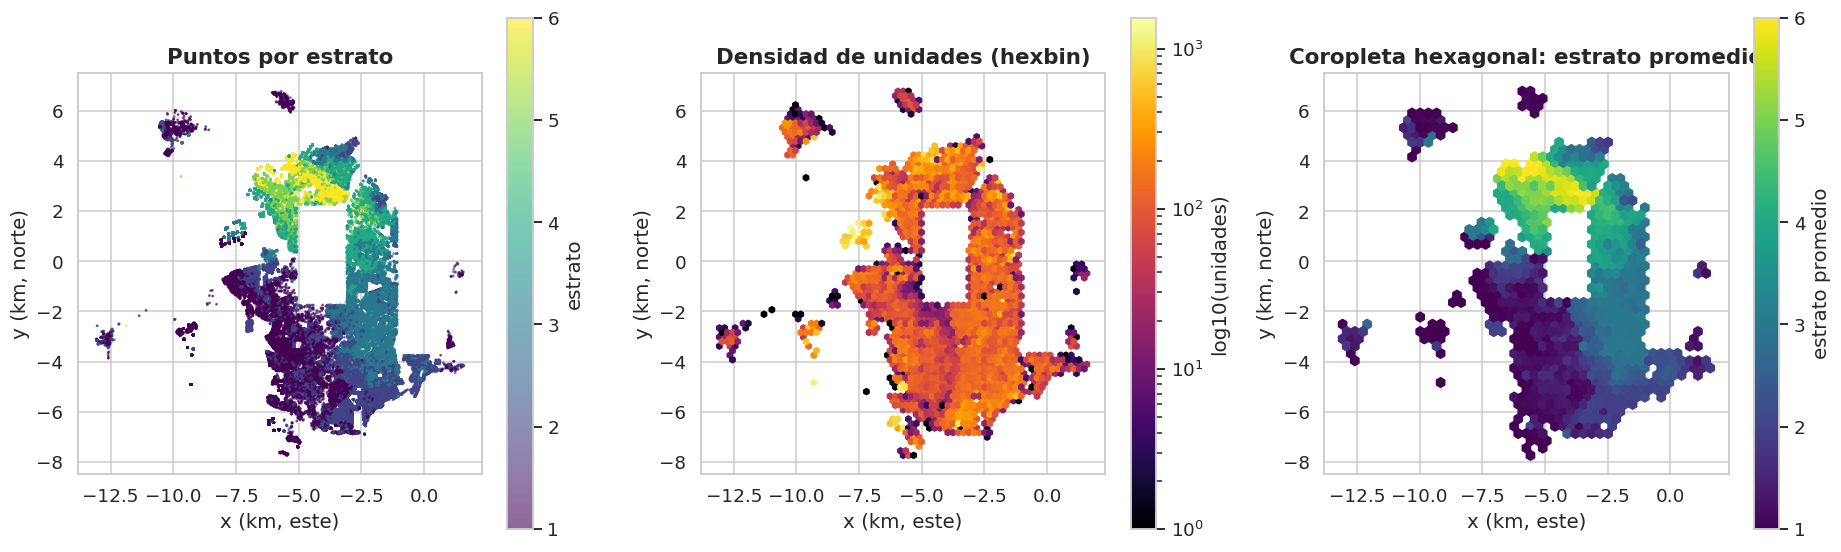

In [5]:
# Tres mapas estáticos en coordenadas proyectadas (km): (1) puntos coloreados por
# estrato, (2) densidad de unidades y (3) estrato promedio por celda hexagonal.
# Juntos separan "dónde hay viviendas" de "qué estrato tienen".
# Muestra de 80 000 puntos: suficiente para ver el patrón sin saturar la figura.
m = train.sample(min(80_000, len(train)), random_state=C.SEED)
fig, axes = plt.subplots(1, 3, figsize=(17, 6.2))
# Panel 1: puntos por estrato. rasterized=True evita un PNG/PDF vectorial enorme.
sc = axes[0].scatter(m["x_km"], m["y_km"], c=m[C.OBJETIVO], cmap="viridis", s=0.8, alpha=0.6, rasterized=True)
plt.colorbar(sc, ax=axes[0], label="estrato", shrink=0.8)
G.ejes_mapa(axes[0], "Puntos por estrato")  # aspecto 1:1 para no deformar distancias
# Panel 2: densidad (unidades por hexágono) en escala log, porque las torres PH
# concentran cientos de unidades en un punto y dominarían una escala lineal.
hb = axes[1].hexbin(train["x_km"], train["y_km"], gridsize=70, bins="log", cmap="inferno", mincnt=1)
plt.colorbar(hb, ax=axes[1], label="log10(unidades)", shrink=0.8)
G.ejes_mapa(axes[1], "Densidad de unidades (hexbin)")
# Panel 3: "coropleta" sobre hexágonos regulares (no hay polígonos de barrio).
# mincnt=5 oculta celdas con menos de 5 unidades, cuyo promedio sería muy ruidoso;
# vmin/vmax fijan la escala a 1-6 para que los colores sean comparables.
hb2 = axes[2].hexbin(train["x_km"], train["y_km"], C=train[C.OBJETIVO], reduce_C_function=np.mean,
                     gridsize=45, cmap="viridis", mincnt=5, vmin=1, vmax=6)
plt.colorbar(hb2, ax=axes[2], label="estrato promedio", shrink=0.8)
G.ejes_mapa(axes[2], "Coropleta hexagonal: estrato promedio")
fig.tight_layout()
G.guardar(fig, "08_mapas_objetivo")
plt.show()

No hay polígonos de barrio o comuna en el servicio de catastro abierto, así
que la "coropleta" se hace sobre celdas hexagonales regulares. Mapas de las
variables más relevantes (mediana por celda):

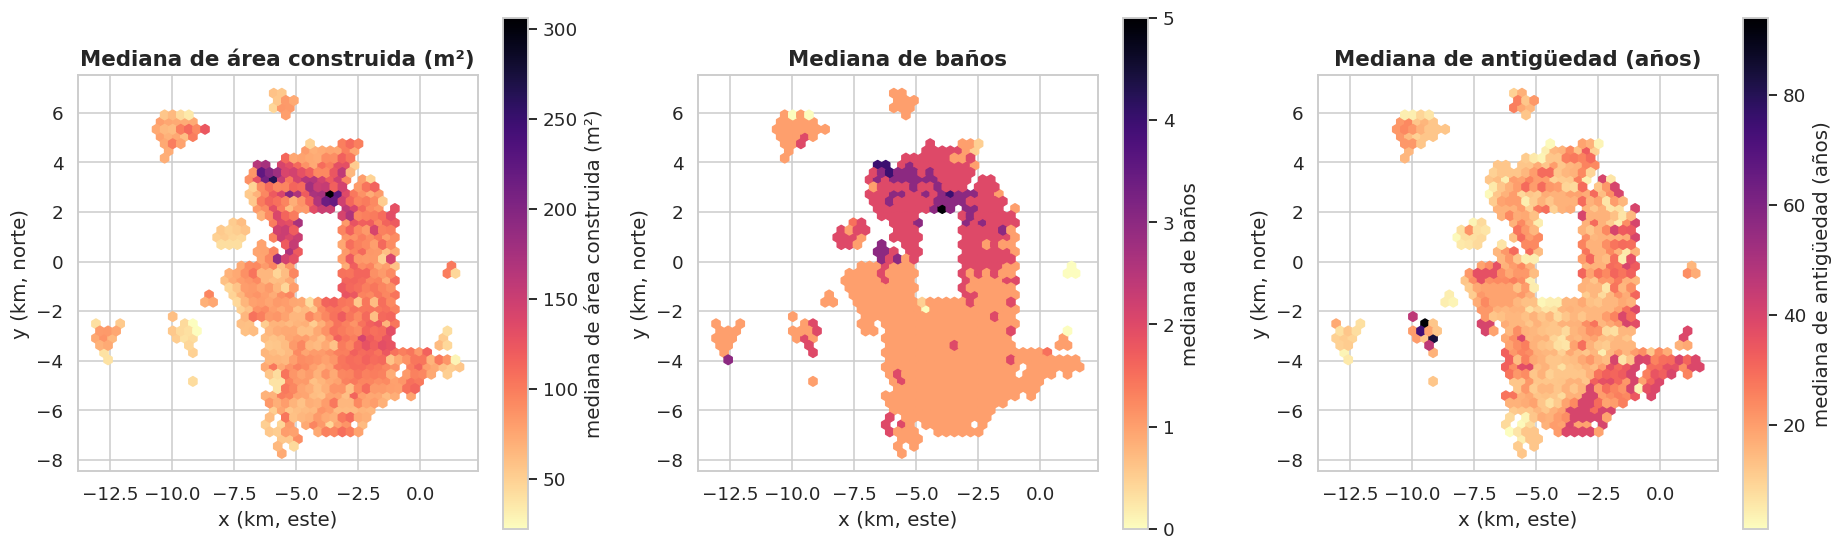

In [6]:
# Mapas de las predictoras físicas más asociadas al estrato (cap. 6). Comparándolos
# con el mapa del estrato se ve si su patrón espacial es similar o si la ubicación
# aporta información que ellas no contienen.
vars_mapa = [("area_construida", "área construida (m²)"), ("total_banios", "baños"),
             ("antiguedad", "antigüedad (años)")]
fig, axes = plt.subplots(1, 3, figsize=(17, 6.2))
for ax, (v, et) in zip(axes, vars_mapa):
    d = train.dropna(subset=[v])  # hexbin no admite NaN en C
    # MEDIANA por celda (no media): estas variables son asimétricas y tienen valores
    # extremos (cap. 5), que distorsionarían el promedio de celdas pequeñas.
    hb = ax.hexbin(d["x_km"], d["y_km"], C=d[v], reduce_C_function=np.median, gridsize=45, cmap="magma_r",
                   mincnt=5)
    plt.colorbar(hb, ax=ax, label=f"mediana de {et}", shrink=0.8)
    G.ejes_mapa(ax, f"Mediana de {et}")
fig.tight_layout()
G.guardar(fig, "08_mapas_variables")
plt.show()

## 8.3 Patrón de puntos y cobertura

Se analiza la ubicación de los **edificios/lotes** (coordenadas únicas) de
**toda la población de modelado (train + test)**. Excepción deliberada a la
regla "solo train": aquí solo se usan **ubicaciones** (no el estrato ni
ninguna otra variable), y si se usara solo train los bloques de prueba
aparecerían como huecos artificiales que sesgarían el índice de
Clark-Evans, la función de Ripley y el mapa de cobertura. Nada de esta
sección alimenta decisiones del modelo.

**Índice del vecino más cercano (Clark-Evans):** R < 1 agrupado, R ≈ 1
aleatorio, R > 1 regular.

In [7]:
# Índice de Clark-Evans: compara la distancia media al vecino más cercano observada
# con la esperada bajo aleatoriedad espacial completa (CSR) de igual densidad.
# Excepción deliberada: se usan ubicaciones de train + test (solo coordenadas, sin
# estrato) para que los bloques de test no aparezcan como huecos artificiales.
ubicaciones = P.cargar_particion()[["x_km", "y_km", "centroide_lat", "centroide_lon"]]
# Coordenadas ÚNICAS: los apartamentos de un edificio comparten centroide y darían
# distancias al vecino de 0 m, lo que simularía un agrupamiento extremo espurio.
xy_unicos = ubicaciones[["x_km", "y_km"]].drop_duplicates().to_numpy()
# Área de referencia = envolvente convexa, sin corrección de borde (limitación leve).
ce = S.clark_evans(xy_unicos)
pd.Series(ce, name="Clark-Evans").to_frame()

,Clark-Evans
n_puntos_unicos,"132,131.0000"
area_km2,149.9038
d_obs_km,0.0094
d_esp_km,0.0168
R,0.5555
z,-309.1214


**Función L de Ripley** (muestra de 3 000 edificios, envolvente de 19
simulaciones de aleatoriedad espacial completa dentro de la envolvente
convexa):

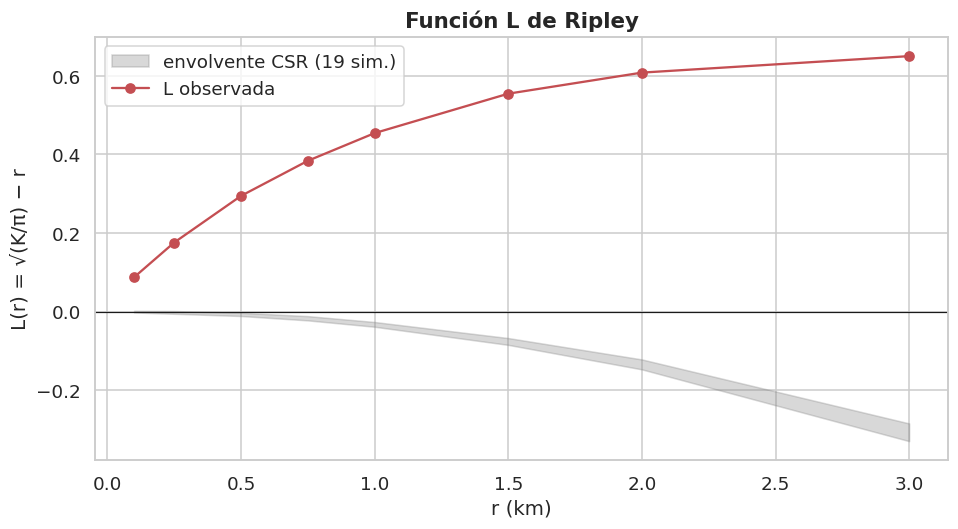

,r_km,L_obs,L_csr_min,L_csr_max
0,0.1000,0.0875,-0.0021,0.0020
1,0.2500,0.1759,-0.0055,0.0015
2,0.5000,0.2946,-0.0111,-0.0029
3,0.7500,0.3839,-0.0223,-0.0114
4,1.0000,0.4543,-0.0385,-0.0264
5,1.5000,0.5547,-0.0846,-0.0673
6,2.0000,0.6083,-0.1470,-0.1217
7,3.0000,0.6503,-0.3296,-0.2845


In [8]:
# Función L de Ripley: a diferencia de Clark-Evans (que solo mira el vecino más
# cercano), evalúa el agrupamiento a VARIAS escalas r. L(r) > 0 y por encima de la
# envolvente de simulaciones CSR indica agrupamiento significativo a esa escala.
# Radios de 100 m (manzana) a 3 km (sector de ciudad).
radios = np.array([0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0])
# n_sim=19: con 19 simulaciones, la envolvente mín-máx equivale a una prueba de
# Monte Carlo con α ≈ 2/(19+1) = 0.10 bilateral (0.05 por lado).
# n_max=3000: K(r) cuenta pares (costo ~n²), por eso se submuestrea.
rip = S.ripley_L(xy_unicos, radios, n_sim=19, n_max=3000, seed=C.SEED)
fig, ax = plt.subplots(figsize=(10, 5))
# Banda gris: rango de L bajo aleatoriedad espacial completa dentro de la envolvente.
ax.fill_between(rip["r_km"], rip["L_csr_min"], rip["L_csr_max"], color="grey", alpha=0.3,
                label="envolvente CSR (19 sim.)")
# Curva roja: L observada; si queda por encima de la banda, hay agrupamiento.
ax.plot(rip["r_km"], rip["L_obs"], "o-", color="#c44e52", label="L observada")
ax.axhline(0, color="k", lw=0.8)  # L = 0: valor esperado teórico bajo CSR
ax.set_xlabel("r (km)")
ax.set_ylabel("L(r) = √(K/π) − r")
ax.set_title("Función L de Ripley")
ax.legend()
G.guardar(fig, "08_ripley")
plt.show()
rip

**Clusters espaciales (DBSCAN con distancia haversine)** sobre una muestra de
20 000 ubicaciones únicas (mínimo 20 vecinos): identifica zonas densas
continuas y puntos aislados. Con un ε grande (300 m) casi todos los puntos
quedan en **un único cluster gigante** (la ciudad es un tejido urbano
continuo a esa escala), así que un ε fijo de antemano no informa. Por eso se
prueba una pequeña rejilla de ε y se elige el **mayor ε cuyo cluster
principal agrupe menos de la mitad de los puntos** (si ninguno lo cumple, el
menor ε). DBSCAN aquí es solo descriptivo: no alimenta al modelo.

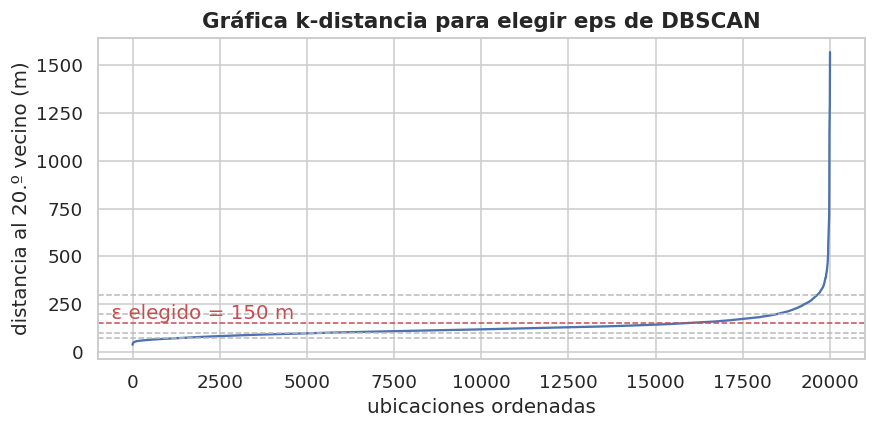

,n_clusters,% en el cluster mayor,% ruido
eps_m,,,
75,57,3.8000,82.3000
100,143,6.5000,47.3000
150,33,45.2000,8.5000
200,18,83.4000,3.0000
300,9,94.0000,0.5000


ε elegido: 150 m | clusters DBSCAN: 33 | puntos aislados (ruido): 8.5%
Tamaño de los 5 clusters mayores: {0: 9045, 2: 3723, 3: 2032, 8: 703, 15: 395}


In [9]:
# DBSCAN descriptivo: identifica zonas densas continuas y puntos aislados sin fijar
# de antemano el número de clusters. Como ε (radio de vecindad) es arbitrario, se
# explora una rejilla de ε y se elige con una regla explícita y reproducible.
# Una fila por coordenada (edificio/lote): si no, un edificio de 200 apartamentos
# cumpliría por sí solo min_samples y crearía "núcleos densos" artificiales.
ed = ubicaciones.drop_duplicates(["centroide_lat", "centroide_lon"])
# Submuestra de 20 000 ubicaciones: DBSCAN con haversine sobre >100 000 puntos es lento.
ed = ed.sample(min(20_000, len(ed)), random_state=C.SEED)
# gráfica k-distancia (k = min_samples): el "codo" orienta la elección de eps
from sklearn.neighbors import NearestNeighbors
# Distancia de cada ubicación a su 20.º vecino (en el plano proyectado, km).
kd, _ = NearestNeighbors(n_neighbors=20).fit(ed[["x_km", "y_km"]]).kneighbors(ed[["x_km", "y_km"]])
fig, ax = plt.subplots(figsize=(9, 3.8))
# Distancias ordenadas en metros: donde la curva se dispara (codo) empiezan los
# puntos aislados; un ε por debajo del codo deja fuera a esos puntos como ruido.
ax.plot(np.sort(kd[:, -1]) * 1000)
ax.set_xlabel("ubicaciones ordenadas")
ax.set_ylabel("distancia al 20.º vecino (m)")
ax.set_title("Gráfica k-distancia para elegir eps de DBSCAN")

# Análisis de sensibilidad: 75, 100, 150, 200 y 300 m.
sens, resultados_db = [], {}
for eps in [0.075, 0.1, 0.15, 0.2, 0.3]:
    # Métrica haversine sobre lat/lon en radianes (distancia real sobre la esfera,
    # no euclidiana sobre grados); min_samples=20 exige ~20 lotes en el radio ε.
    et = S.dbscan_haversine(ed["centroide_lat"].to_numpy(), ed["centroide_lon"].to_numpy(),
                            eps_km=eps, min_samples=20)
    # Tamaño de cada cluster (etiqueta -1 = ruido, se excluye), de mayor a menor.
    tam = pd.Series(et[et >= 0]).value_counts()
    resultados_db[eps] = et
    sens.append({"eps_m": int(eps * 1000), "n_clusters": len(tam),
                 "% en el cluster mayor": 100 * (tam.iloc[0] if len(tam) else 0) / len(et),
                 "% ruido": 100 * (et == -1).mean()})
sens = pd.DataFrame(sens).set_index("eps_m")
# Regla de elección: el MAYOR ε cuyo cluster principal agrupe < 50 % de los puntos.
# Un ε mayor fusiona toda la ciudad en un bloque (no informa); uno menor dispara el
# ruido. Si ningún ε cumple la regla, se toma el menor de la rejilla.
validos = sens.index[sens["% en el cluster mayor"] < 50]
eps_m = int(validos.max()) if len(validos) else int(sens.index.min())
# Líneas horizontales sobre la gráfica k-distancia: ε probados (gris) y elegido (rojo).
for e_ in sens.index:
    ax.axhline(e_, color="#c44e52" if e_ == eps_m else "#bbbbbb", ls="--", lw=1)
ax.text(0.01, eps_m, f" ε elegido = {eps_m} m", color="#c44e52", va="bottom",
        transform=ax.get_yaxis_transform())
plt.show()
display(sens.round(1))
etiquetas = resultados_db[eps_m / 1000]
# Número de clusters sin contar la etiqueta de ruido (-1).
n_cl = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
print(f"ε elegido: {eps_m} m | clusters DBSCAN: {n_cl} | puntos aislados (ruido): "
      f"{100 * (etiquetas == -1).mean():.1f}%")
tam_cl = pd.Series(etiquetas[etiquetas >= 0]).value_counts()
print("Tamaño de los 5 clusters mayores:", tam_cl.head().to_dict())

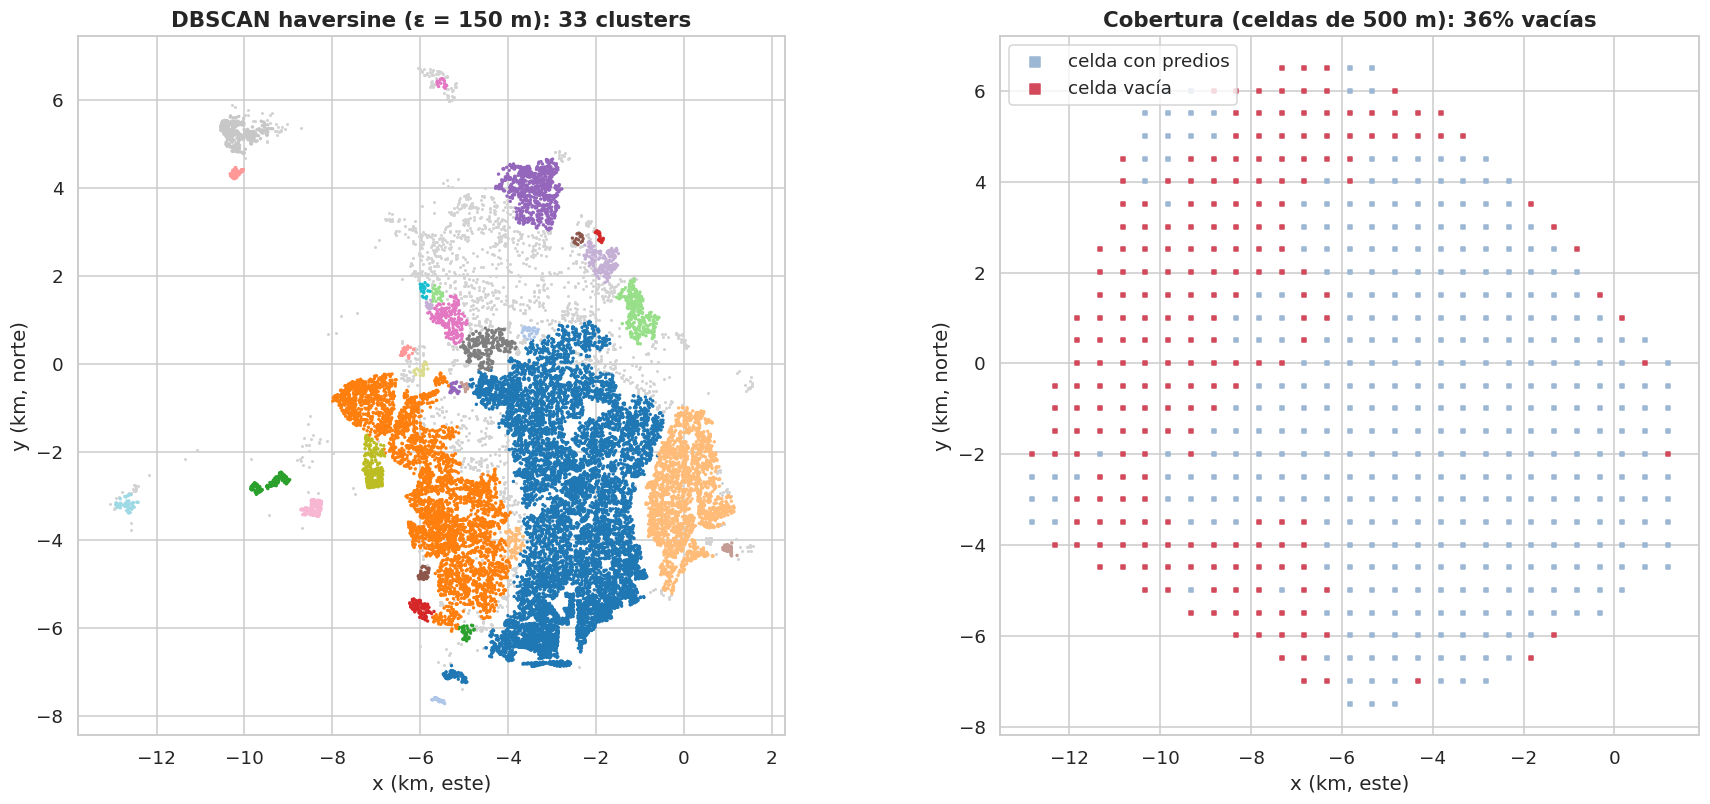

In [10]:
# Izquierda: clusters DBSCAN con el ε elegido. Derecha: cobertura espacial, es decir,
# qué celdas de 500 m dentro del área urbana no tienen ningún predio ubicado; sirve
# para detectar sesgo de muestreo espacial (zonas que el modelo nunca verá).
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
ax = axes[0]
# Ruido en gris claro, debajo; los clusters encima con 20 colores cíclicos.
ax.scatter(ed["x_km"][etiquetas == -1], ed["y_km"][etiquetas == -1], s=1, c="lightgrey", label="ruido")
# "% 20": tab20 tiene 20 colores; con más clusters se reciclan (solo es visual).
ax.scatter(ed["x_km"][etiquetas >= 0], ed["y_km"][etiquetas >= 0], s=1.5, c=etiquetas[etiquetas >= 0] % 20,
           cmap="tab20")
G.ejes_mapa(ax, f"DBSCAN haversine (ε = {eps_m} m): {n_cl} clusters")
# cobertura: celdas de 500 m dentro de la envolvente sin ningún predio
from matplotlib.path import Path as MPath
from scipy.spatial import ConvexHull
# La envolvente convexa de todas las ubicaciones delimita el "área de estudio";
# solo se evalúan celdas cuyo centro cae dentro de ella.
hull = ConvexHull(xy_unicos)
camino = MPath(xy_unicos[hull.vertices])
paso = 0.5  # lado de la celda en km (500 m, escala de unas pocas manzanas)
# Centros de una grilla regular que cubre la caja de las ubicaciones.
gx, gy = np.meshgrid(np.arange(xy_unicos[:, 0].min(), xy_unicos[:, 0].max(), paso) + paso / 2,
                     np.arange(xy_unicos[:, 1].min(), xy_unicos[:, 1].max(), paso) + paso / 2)
centros = np.column_stack([gx.ravel(), gy.ravel()])
dentro = camino.contains_points(centros)
# Índices (columna, fila) de celda de cada ubicación: conjunto de celdas ocupadas.
ocupadas = set(map(tuple, np.floor((xy_unicos - xy_unicos.min(0)) / paso).astype(int)))
# Mismo índice para los centros de la grilla; una celda es "vacía" si está dentro de
# la envolvente y ninguna ubicación cae en ella.
idx_c = np.floor((centros - xy_unicos.min(0)) / paso).astype(int)
vacia = np.array([tuple(t) not in ocupadas for t in idx_c]) & dentro
# Azul: celdas con predios; rojo: celdas vacías (el título da el % de vacías).
axes[1].scatter(centros[dentro & ~vacia, 0], centros[dentro & ~vacia, 1], s=9, c="#9bb7d4", marker="s",
                label="celda con predios")
axes[1].scatter(centros[vacia, 0], centros[vacia, 1], s=9, c="#d1495b", marker="s", label="celda vacía")
G.ejes_mapa(axes[1], f"Cobertura (celdas de 500 m): {100 * vacia.sum() / dentro.sum():.0f}% vacías")
axes[1].legend(loc="upper left", markerscale=2)
fig.tight_layout()
G.guardar(fig, "08_dbscan_cobertura")
plt.show()

```{admonition} Interpretación
:class: note
- **Agrupamiento fuerte.** Con 132 131 ubicaciones únicas en ~150 km², la
  distancia media al vecino más cercano es 9.4 m frente a 16.8 m esperados
  bajo aleatoriedad: **R de Clark-Evans = 0.56** (z = −309). La función L de
  Ripley está muy por encima de la envolvente de aleatoriedad en todas las
  escalas, de 100 m a 3 km. Los predios están **agrupados**, como es de
  esperar en una ciudad: manzanas densas separadas por vías, parques y
  cuerpos de agua.
- **DBSCAN.** Con ε = 300 m, el **94 % de los puntos cae en un único
  cluster** y solo 0.5 % es ruido: a esa escala Barranquilla es un **tejido
  urbano continuo**, y los otros 8 clusters suman apenas el 5.5 % restante.
  Con 200 m el cluster mayor aún reúne el 83 %. Al reducir ε el bloque se
  fragmenta: con **ε = 150 m** (el elegido: el mayor con el que ningún
  cluster concentra más de la mitad de los puntos) hay **33 clusters**, el
  mayor con el 45 % de los puntos (9 045 de 20 000) y 8.5 % de ruido. Con
  100 m el ruido sube al 47 % (143 clusters pequeños) y con 75 m al 82 %.
  A 150 m, el núcleo centro-sur sigue siendo un solo bloque denso; el
  suroccidente (3 723 puntos) y el oriente (2 032) forman los dos clusters
  siguientes, mientras que buena parte del norte queda como ruido o como
  clusters compactos: allí hay menos *ubicaciones únicas* por km², porque
  predominan torres PH (muchas unidades con un mismo centroide) y lotes más
  grandes.
- **Cobertura.** El **36 %** de las celdas de 500 m dentro de la envolvente
  convexa no tiene ningún predio ubicado. La mayoría están en la periferia
  occidental y norte, donde el mapa muestra solo enclaves aislados. Parte
  son zonas sin uso residencial (industria, humedales, vías, suelo rural),
  pero parte pueden ser **asentamientos informales no ubicables** (cap. 2:
  el 16.2 % de las filas limpias no tiene coordenadas; cap. 3: el 99.5 % de
  ellas son predios informales y el 96.5 % son estratos 1–2). Es un **sesgo
  de muestreo espacial**: el modelo no ve esas zonas.
```

## 8.4 Autocorrelación espacial

**Matriz de pesos.** Se usan los **k = 8 vecinos más cercanos**,
fila-estandarizada. Justificación: la densidad de predios es muy desigual
(centro denso, periferia dispersa); con una banda de distancia fija, en la
periferia habría puntos sin vecinos y en el centro puntos con cientos. Con
kNN todos tienen el mismo número de vecinos. La contigüidad (reina/torre)
requeriría polígonos que no tenemos a nivel de edificio. Para no inflar el
índice con unidades del mismo edificio (misma coordenada, mismo estrato), se
trabaja con **una fila por edificio** sobre una muestra estratificada.

In [11]:
# Construcción de la base para autocorrelación: muestra estratificada de train,
# reducida a UNA fila por edificio, y matriz de pesos espaciales de k vecinos.
# Muestra estratificada de 25 000 unidades: conserva las proporciones de estrato y
# mantiene manejable el costo de las permutaciones (Moran, LISA).
muestra = S.muestra_estratificada(train, C.N_MUESTRA_ESPACIAL)
# Deduplicación por edificio (prefijo NPN de 22 dígitos o, si falta, coordenada):
# las unidades de un edificio comparten centroide y casi siempre estrato; dejarlas
# como vecinos entre sí inflaría Moran's I con "autocorrelación" trivial. Las
# variables numéricas quedan promediadas por edificio.
edif = S.deduplicar_por_edificio(muestra)
print(f"Muestra: {len(muestra):,} unidades -> {len(edif):,} edificios únicos "
      f"({100 * (1 - len(edif) / len(muestra)):.1f}% eran unidades del mismo edificio)")
xy = edif[["x_km", "y_km"]].to_numpy()  # coordenadas proyectadas: distancias en km
# W: k = 8 vecinos más cercanos, fila-estandarizada (cada vecino pesa 1/8). kNN en
# vez de banda de distancia porque la densidad es muy desigual: garantiza el mismo
# número de vecinos a todos. k = 8 es un valor habitual (análogo a la contigüidad
# reina de una grilla) que da un rezago estable sin alejarse demasiado del punto.
# dist_vec e idx_vec (distancias e índices de los vecinos) se reutilizan en LISA y Gi*.
W, dist_vec, idx_vec = S.pesos_knn(xy, k=C.K_VECINOS)
# Escala real de la "vecindad" que define W (en metros).
print(f"Distancia a los {C.K_VECINOS} vecinos: media {dist_vec.mean() * 1000:.0f} m, "
      f"mediana {np.median(dist_vec) * 1000:.0f} m")

Muestra: 25,000 unidades -> 15,042 edificios únicos (39.8% eran unidades del mismo edificio)
Distancia a los 8 vecinos: media 61 m, mediana 55 m


In [12]:
# Moran's I global del estrato y de tres predictoras físicas: cuantifica cuánto se
# parecen los edificios vecinos. Compararlos dice si la ubicación aporta información
# sobre el estrato más allá de lo que ya explican las variables físicas.
filas = []
for v in [C.OBJETIVO, "area_construida", "total_banios", "antiguedad"]:
    # Imputación por mediana solo para este cálculo descriptivo (Moran no admite NaN).
    x = edif[v].fillna(edif[v].median()).to_numpy()
    # Inferencia por permutación (999 reordenamientos aleatorios de los valores sobre
    # las ubicaciones): no supone normalidad; con 999 el p-valor mínimo alcanzable es
    # 1/(999+1) = 0.001. Se reporta también z respecto a la distribución permutada.
    r = S.moran_global(x, W, n_perm=999, seed=C.SEED)
    filas.append({"variable": v, **r})
moran = pd.DataFrame(filas).set_index("variable")
moran

,I,E[I],media_perm,sd_perm,z,p_perm,n,n_perm
variable,,,,,,,,
estrato_num,0.9130,-0.0001,-0.0001,0.0040,229.3784,0.0010,15042,999
area_construida,0.2183,-0.0001,-0.0000,0.0039,55.7505,0.0010,15042,999
total_banios,0.3385,-0.0001,0.0000,0.0038,88.0343,0.0010,15042,999
antiguedad,0.3571,-0.0001,0.0000,0.0039,91.6327,0.0010,15042,999


```{admonition} Interpretación
:class: note
- La muestra de 25 000 unidades se reduce a **15 042 edificios** (el 40 %
  eran unidades repetidas del mismo edificio). Cada edificio tiene sus 8
  vecinos a una distancia mediana de 55 m (media de 61 m).
- **Moran's I del estrato = 0.913** (z = 229, p = 0.001 con 999
  permutaciones; bajo aleatoriedad se esperaría ≈ 0): una autocorrelación
  **positiva extremadamente fuerte**. Edificios vecinos casi siempre tienen
  el mismo estrato, lo que refleja que la estratificación se asigna por
  manzanas y zonas homogéneas: la ciudad está fuertemente **segregada** por
  estrato.
- Las predictoras físicas también están autocorrelacionadas, pero mucho
  menos: antigüedad 0.36, baños 0.34, área construida 0.22. El tipo de
  construcción se agrupa por zonas, pero el estrato se agrupa **mucho más**
  que cualquier característica física. Consecuencia: la ubicación contiene
  información sobre el estrato que las variables físicas no recogen.
```

### Indicadores locales (LISA) y hotspots (Getis-Ord Gi*)

In [13]:
# Indicadores LOCALES: Moran global resume toda la ciudad en un número; LISA y Gi*
# dicen DÓNDE están los clusters de estratos altos/bajos y si hay outliers espaciales.
# LISA (Moran local, Anselin 1995): I_i = z_i · promedio de z en sus 8 vecinos.
# p-valor por aleatorización condicional (se fija el valor de i y se sortean sus
# vecinos). 199 permutaciones (p mínimo 0.005) bastan aquí y abaratan el cálculo,
# que se repite para cada uno de los ~15 000 edificios.
lis = S.lisa(edif[C.OBJETIVO].to_numpy(), idx_vec, n_perm=199, seed=C.SEED)
# Gi* (Getis-Ord): suma local del estrato INCLUYENDO al propio punto, estandarizada;
# devuelve un z: z > 1.96 hotspot (altos rodeados de altos), z < -1.96 coldspot.
gi = S.getis_ord_gi_star(edif[C.OBJETIVO].to_numpy(), idx_vec)
# Conteo de edificios por cuadrante LISA (HH, LL, HL, LH o no significativo a 5 %).
tabla_lisa = lis["cuadrante"].value_counts().to_frame("edificios")
tabla_lisa["%"] = 100 * tabla_lisa["edificios"] / len(lis)
# Se hacen miles de pruebas simultáneas (una por edificio): con α = 0.05 habría ~5 %
# de "hotspots" por puro azar. Benjamini-Hochberg controla la tasa de falsos
# descubrimientos (FDR) y es menos conservador que Bonferroni/Holm con tantas
# pruebas. p-valor bilateral normal: 2·P(Z > |z|).
p_gi_bh = E.ajuste_bh(2 * stats.norm.sf(np.abs(gi)))
# Porcentaje de hot/coldspots sin ajuste y con FDR, para ver cuánto cambia.
print(f"Gi*: hotspots (z > 1.96) {100 * (gi > 1.96).mean():.1f}%, coldspots (z < -1.96) {100 * (gi < -1.96).mean():.1f}% "
      f"| con FDR (BH): hot {100 * ((gi > 0) & (p_gi_bh < 0.05)).mean():.1f}%, "
      f"cold {100 * ((gi < 0) & (p_gi_bh < 0.05)).mean():.1f}%")
tabla_lisa

Gi*: hotspots (z > 1.96) 19.7%, coldspots (z < -1.96) 29.5% | con FDR (BH): hot 18.9%, cold 27.2%


,edificios,%
cuadrante,,
no significativo,8009,53.2442
LL,4162,27.6692
HH,2851,18.9536
HL,15,0.0997
LH,5,0.0332


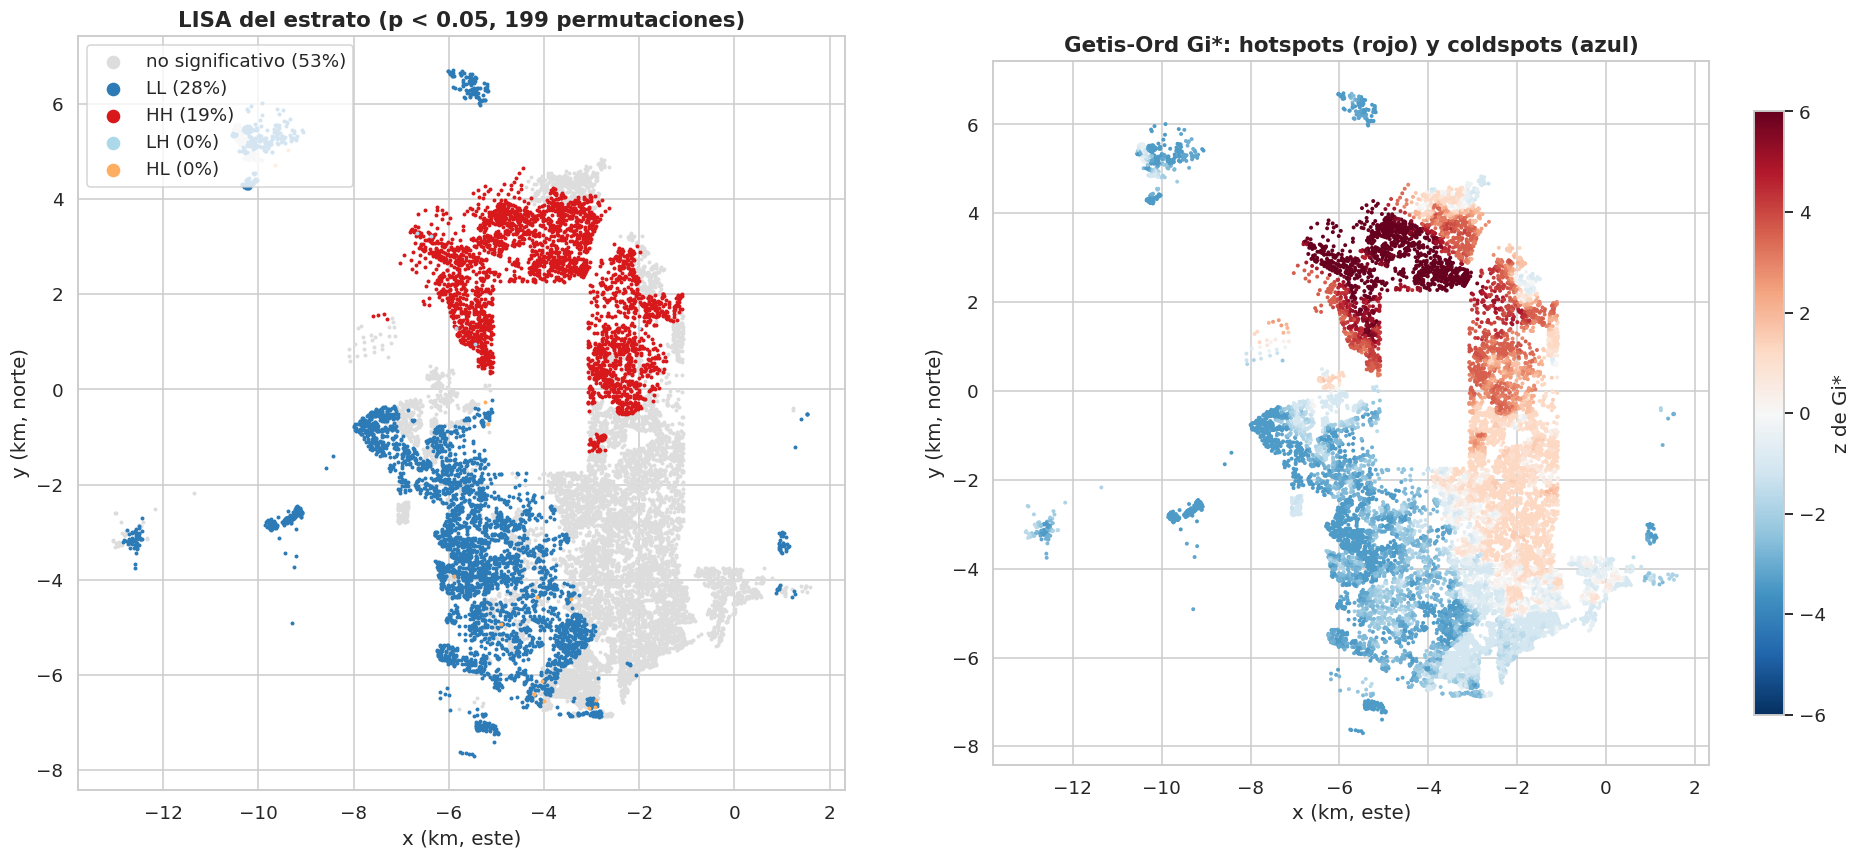

In [14]:
# Mapas de los indicadores locales. Izquierda: cuadrantes LISA significativos (rojo
# HH = alto rodeado de alto, azul LL = bajo rodeado de bajo, tonos claros = outliers
# HL/LH, gris = no significativo). Derecha: z de Gi* (rojo hotspot, azul coldspot).
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# Colores convencionales de los mapas LISA (GeoDa).
col_lisa = {"HH": "#d7191c", "LL": "#2c7bb6", "HL": "#fdae61", "LH": "#abd9e9", "no significativo": "#dddddd"}
# Orden de dibujo: primero los no significativos, para que no tapen a los clusters.
for c in ["no significativo", "LL", "HH", "LH", "HL"]:
    mk = lis["cuadrante"] == c
    axes[0].scatter(xy[mk, 0], xy[mk, 1], s=2.5, c=col_lisa[c], label=f"{c} ({mk.mean():.0%})")
G.ejes_mapa(axes[0], "LISA del estrato (p < 0.05, 199 permutaciones)")
axes[0].legend(markerscale=5, loc="upper left")
# Se recorta z a [-6, 6] y se centra la paleta divergente en 0: unos pocos z
# extremos no deben comprimir el contraste del resto del mapa.
sc = axes[1].scatter(xy[:, 0], xy[:, 1], s=2.5, c=np.clip(gi, -6, 6), cmap="RdBu_r", vmin=-6, vmax=6)
plt.colorbar(sc, ax=axes[1], label="z de Gi*", shrink=0.8)
G.ejes_mapa(axes[1], "Getis-Ord Gi*: hotspots (rojo) y coldspots (azul)")
fig.tight_layout()
G.guardar(fig, "08_lisa_gi")
plt.show()

LISA y Gi* hacen muchas pruebas a la vez (una por edificio); con α = 0.05
se esperaría ~5 % de falsos positivos aunque no hubiera patrón. Con el
ajuste de Benjamini-Hochberg (FDR) la proporción significativa cambia así:

In [15]:
# Corrección por comparaciones múltiples de los pseudo p-valores de LISA con
# Benjamini-Hochberg (FDR): si la proporción significativa apenas cambia, el patrón
# no es un artefacto de hacer una prueba por edificio.
p_bh = E.ajuste_bh(lis["p"].to_numpy())
print(f"Significativos a 5%: sin ajuste {100 * (lis['p'] < 0.05).mean():.1f}% | con FDR (BH) {100 * (p_bh < 0.05).mean():.1f}%")

Significativos a 5%: sin ajuste 46.8% | con FDR (BH) 41.8%


```{admonition} Interpretación de LISA y Gi*
:class: note
- Sin ajuste, el **46.8 %** de los edificios tiene un LISA significativo;
  con FDR (Benjamini-Hochberg), el **41.8 %**. La corrección apenas cambia
  el cuadro: el patrón no es un artefacto de hacer miles de pruebas.
- Casi todo lo significativo son **clusters homogéneos**: 27.7 % LL (bajo
  rodeado de bajo) y 19.0 % HH (alto rodeado de alto). Los **outliers
  espaciales** son rarísimos: 15 HL y 5 LH, 20 edificios en total (0.1 %).
  Un edificio de estrato alto rodeado de estratos bajos casi no existe.
- Gi* coincide: 27.2 % de *coldspots* y 18.9 % de *hotspots* tras FDR
  (29.5 % y 19.7 % sin ajuste). En el mapa, los hotspots forman un arco
  continuo en el norte que baja por el oriente hacia el centro, y los
  coldspots cubren el occidente y el suroccidente, además de los enclaves
  periféricos aislados. El centro-sur y el sureste quedan mayormente como no
  significativos en LISA y con z de Gi* moderados: son zonas de estratos
  intermedios o mezclados, que no forman clusters homogéneos.
```

### Correlograma y semivariograma

Moran's I y semivarianza por bandas de distancia (pares de edificios de una
submuestra de 4 000). Muestran **hasta qué distancia** dos edificios siguen
pareciéndose en estrato: ese **alcance** es la referencia para el tamaño del
buffer de la validación espacial.

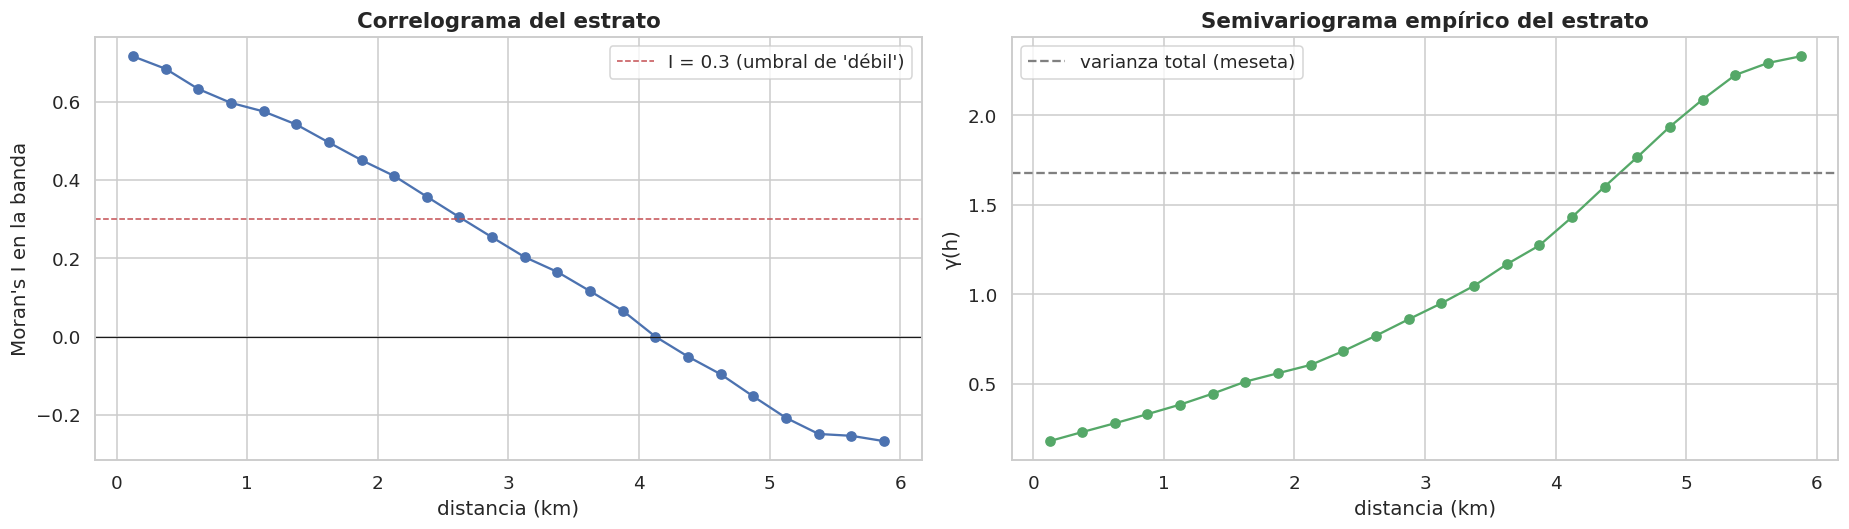

In [16]:
# Correlograma (Moran's I por banda de distancia) y semivariograma empírico del
# estrato. Responden "¿hasta qué distancia dos edificios se siguen pareciendo?":
# ese alcance es la referencia objetiva para el buffer de la validación espacial.
# Bandas de 250 m entre 0 y 6 km (más allá del tamaño de bloque de 2 km).
bandas = np.arange(0, 6.25, 0.25)
# Submuestra de 4 000 edificios: ~8 millones de pares, suficiente y manejable en
# memoria (el cálculo usa TODAS las distancias por pares, costo n²).
corr = S.correlograma(xy, edif[C.OBJETIVO].to_numpy(), bandas, n_max=4000, seed=C.SEED)
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
# Izquierda: I en cada banda; decrece con la distancia a medida que se pierde el parecido.
axes[0].plot(corr["centro_km"], corr["moran_I"], "o-", color="#4c72b0")
axes[0].axhline(0, color="k", lw=0.8)
# Umbral convencional de 0.3: por debajo, la correlación se considera débil.
axes[0].axhline(0.3, color="#c44e52", ls="--", lw=1, label="I = 0.3 (umbral de 'débil')")
axes[0].set_xlabel("distancia (km)")
axes[0].set_ylabel("Moran's I en la banda")
axes[0].set_title("Correlograma del estrato")
axes[0].legend()
# Derecha: semivarianza γ(h) = ½·media[(x_i − x_j)²] de los pares a distancia h;
# crece con h hasta la "meseta" (varianza total), cuando los pares ya son independientes.
axes[1].plot(corr["centro_km"], corr["semivarianza"], "o-", color="#55a868")
axes[1].axhline(corr["varianza_total"].iloc[0], color="grey", ls="--", label="varianza total (meseta)")
axes[1].set_xlabel("distancia (km)")
axes[1].set_ylabel("γ(h)")
axes[1].set_title("Semivariograma empírico del estrato")
axes[1].legend()
fig.tight_layout()
G.guardar(fig, "08_correlograma")
plt.show()

In [17]:
# Traduce el correlograma en una decisión: el alcance es la primera banda donde
# Moran's I cae por debajo de 0.3, y el buffer propuesto es ese alcance recortado.
bajo = corr[corr["moran_I"] < 0.3]
# Si I nunca baja de 0.3 en el rango explorado, se toma la última banda (6 km).
alcance = float(bajo["centro_km"].iloc[0]) if len(bajo) else float(corr["centro_km"].iloc[-1])
# Recorte a [0.25, 1.0] km: mínimo de 250 m para cortar al menos la dependencia de
# manzana; máximo de 1 km porque un buffer mayor excluye demasiado entrenamiento
# (ver la tabla de costos siguiente). Es un compromiso explícito sesgo-varianza.
buffer_km = float(np.clip(alcance, 0.25, 1.0))
print(f"Distancia a la que Moran's I cae por debajo de 0.3: {alcance:.2f} km")
print(f"Buffer propuesto (recortado a [0.25, 1.0] km): {buffer_km:.2f} km")

Distancia a la que Moran's I cae por debajo de 0.3: 2.88 km
Buffer propuesto (recortado a [0.25, 1.0] km): 1.00 km


¿Cuánto entrenamiento se pierde con cada buffer? Se mide dentro de train,
con el mismo procedimiento de folds que usará la validación cruzada del
modelo (bloques de 2 km, `folds_estratificados_por_grupo`, semilla fija).
Aquí se aplica a todo train; en el capítulo 10 se aplica al train que queda
después de excluir el buffer frente a test, así que los folds y las
fracciones excluidas allí no son idénticos a los de esta tabla:

In [18]:
# Costo de cada buffer: qué fracción del entrenamiento de cada fold se descarta por
# estar a menos de b km de la validación. Mismo procedimiento de folds que la CV del
# modelo (bloques de 2 km, folds_estratificados_por_grupo, semilla fija), aplicado
# aquí a todo train.
costos = []
for b in [0.0, 0.25, 0.5, 0.75, 1.0]:
    folds = P.folds_espaciales_con_buffer(train, b, verbose=False)
    # len(train) - len(va) = entrenamiento disponible sin buffer; len(tr) = el que
    # queda tras excluir los puntos dentro del buffer. Se promedia sobre los 5 folds.
    perdida = np.mean([1 - len(tr) / (len(train) - len(va)) for tr, va in folds])
    costos.append({"buffer_km": b, "% de train excluido (media por fold)": 100 * perdida})
pd.DataFrame(costos)

,buffer_km,% de train excluido (media por fold)
0,0.0000,0.0000
1,0.2500,8.1100
2,0.5000,17.0299
3,0.7500,26.0762
4,1.0000,35.7126


In [19]:
# Registro de decisiones (decisiones_eda.json): los capítulos de modelado leen estos
# valores en vez de fijarlos a mano, de modo que cada parámetro queda trazado al
# hallazgo del EDA que lo justificó (buffer, alcance y k de la matriz de pesos).
C.guardar_decision("buffer_km", buffer_km,
                   f"Correlograma en train (cap. 8.4): Moran's I del estrato cae por debajo de 0.3 a ~{alcance:.2f} km; "
                   "se recorta a [0.25, 1.0] km para no perder demasiado entrenamiento.")
C.guardar_decision("alcance_correlograma_km", alcance,
                   "Distancia a la que el Moran's I del estrato baja de 0.3 (cap. 8.4); referencia para el "
                   "análisis de sensibilidad del buffer (cap. 10).")
C.guardar_decision("k_vecinos", C.K_VECINOS, "Densidad muy desigual: kNN garantiza vecinos para todos (cap. 8.4).")

[decisión registrada] buffer_km = 1.0
   motivo: Correlograma en train (cap. 8.4): Moran's I del estrato cae por debajo de 0.3 a ~2.88 km; se recorta a [0.25, 1.0] km para no perder demasiado entrenamiento.
[decisión registrada] alcance_correlograma_km = 2.875
   motivo: Distancia a la que el Moran's I del estrato baja de 0.3 (cap. 8.4); referencia para el análisis de sensibilidad del buffer (cap. 10).
[decisión registrada] k_vecinos = 8
   motivo: Densidad muy desigual: kNN garantiza vecinos para todos (cap. 8.4).


```{admonition} Interpretación del correlograma y del buffer
:class: important
- Moran's I del estrato baja lentamente con la distancia y solo cae por
  debajo de 0.3 a **≈ 2.9 km** (banda centrada en 2.875 km): dos edificios
  a 2 km siguen pareciéndose bastante en estrato. Ese es el **alcance** de
  la dependencia espacial.
- A distancias mayores el Moran por banda se vuelve negativo y el
  semivariograma no se estabiliza en una meseta: sigue creciendo y supera
  la varianza total. Es la huella de la **tendencia norte-sur de gran
  escala** (los pares muy alejados suelen ser norte frente a sur), que las
  coordenadas como predictoras pueden recoger.
- Un buffer de 2.9 km dejaría sin entrenamiento a la mayor parte de train:
  ya con 1 km se excluye en promedio el **35.7 %** de train en cada fold
  (8.1 % con 250 m, 17.0 % con 500 m, 26.1 % con 750 m). **Decisión:** buffer de
  **1 km** (tope del recorte). Es un compromiso consciente: la separación
  entre train y validación es **parcial** (queda dependencia entre 1 y
  2.9 km), así que la validación espacial sigue siendo algo optimista. El
  capítulo 10 mide cuánto cambia el F1 con buffers de 0, 0.5, 1 y 2.9 km.
```

## 8.5 Heterogeneidad espacial

¿La relación entre las predictoras y el estrato es la misma en toda la
ciudad? Se divide el área de train en una grilla de 3 × 3 **macrozonas** y
se calcula, en cada una, el estrato medio y la correlación de Spearman entre
el área construida y el estrato.

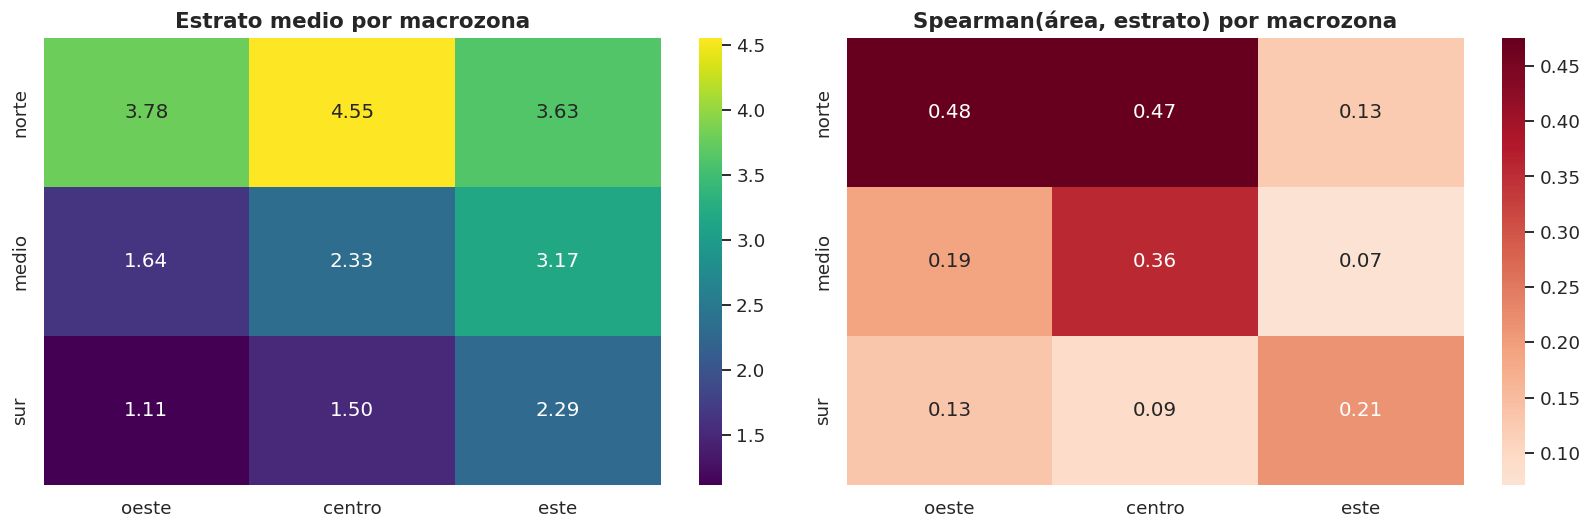

n  estrato_medio  rho_area_estrato  rho_banios_estrato
zona_y zona_x                                                                 
sur    oeste  15,830.0000         1.1092            0.1328              0.1090
       centro 27,413.0000         1.4990            0.0905              0.1358
       este   29,714.0000         2.2898            0.2134              0.1478
medio  oeste  31,713.0000         1.6443            0.1904              0.2454
       centro 10,311.0000         2.3316            0.3586              0.4850
       este   30,932.0000         3.1651            0.0706              0.2260
norte  oeste  25,428.0000         3.7841            0.4755              0.5753
       centro 35,218.0000         4.5549            0.4709              0.4227
       este   12,311.0000         3.6254            0.1255              0.2995

In [20]:
# Heterogeneidad espacial (no estacionariedad): ¿la relación predictora-estrato es
# la misma en toda la ciudad? Se divide train en 3 × 3 macrozonas y en cada una se
# calculan el estrato medio y la correlación de Spearman área-estrato y baños-estrato.
t = train.copy()  # copia para no añadir columnas auxiliares a train
# Terciles (qcut) en vez de cortes de igual ancho: cada franja tiene ~1/3 de las
# unidades, así ninguna macrozona queda con muy pocas observaciones.
t["zona_x"] = pd.qcut(t["x_km"], 3, labels=["oeste", "centro", "este"])
t["zona_y"] = pd.qcut(t["y_km"], 3, labels=["sur", "medio", "norte"])
# Spearman (por rangos) porque el estrato es ordinal y la relación puede ser monótona
# pero no lineal; nan_policy="omit" ignora faltantes sin imputar.
het = t.groupby(["zona_y", "zona_x"], observed=True).apply(
    lambda g: pd.Series({"n": len(g), "estrato_medio": g[C.OBJETIVO].mean(),
                         "rho_area_estrato": stats.spearmanr(g["area_construida"], g[C.OBJETIVO],
                                                             nan_policy="omit")[0],
                         "rho_banios_estrato": stats.spearmanr(g["total_banios"], g[C.OBJETIVO],
                                                               nan_policy="omit")[0]}),
    include_groups=False)
# Dos mapas de calor 3 × 3 (norte arriba): estrato medio y ρ(área, estrato).
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, cm, t_ in [(axes[0], "estrato_medio", "viridis", "Estrato medio por macrozona"),
                        (axes[1], "rho_area_estrato", "RdBu_r", "Spearman(área, estrato) por macrozona")]:
    # unstack -> filas = zona_y, columnas = zona_x; iloc[::-1] invierte las filas para
    # que "norte" quede arriba, como en un mapa.
    piv = het[col].unstack().iloc[::-1]
    # La paleta divergente de ρ se centra en 0 (sin relación); el estrato medio no.
    sns.heatmap(piv, annot=True, fmt=".2f", cmap=cm, ax=ax, center=None if col == "estrato_medio" else 0)
    ax.set_title(t_)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.tight_layout()
G.guardar(fig, "08_heterogeneidad")
plt.show()
het

```{admonition} Interpretación
:class: note
- El estrato medio va de **1.1** en la macrozona sur-oeste a **4.6** en la
  norte-centro: el gradiente norte-sur del cap. 4 se confirma, con un
  gradiente oeste-este adicional en el sur y en la franja media (sur: 1.1 →
  1.5 → 2.3; medio: 1.6 → 2.3 → 3.2). En el norte el máximo está en el
  centro (oeste 3.8, centro 4.6, este 3.6).
- **La relación física–estrato no es la misma en toda la ciudad.** La
  correlación de Spearman entre área construida y estrato va de **0.07**
  (medio-este) y 0.09 (sur-centro) a **0.47–0.48** en el norte-oeste y el
  norte-centro (pero solo 0.13 en el norte-este); la de baños, de 0.11
  (sur-oeste) a **0.58** (norte-oeste). En el sur, casi todo es estrato 1–2
  y el tamaño de la vivienda apenas discrimina; en el norte-oeste y el
  norte-centro, donde conviven estratos altos y medios, el tamaño y los
  baños sí separan.
- Esto es **heterogeneidad espacial** (no estacionariedad): el peso de una
  característica física para predecir el estrato depende de dónde esté la
  vivienda. Un modelo global lineal como la regresión logística no captura
  esto; las coordenadas como predictoras capturan solo la **tendencia de gran
  escala**. Modelos con interacciones, árboles o regresión geográficamente
  ponderada (GWR) quedan como trabajo futuro.
```

## 8.6 Efecto de la escala (MAUP)

El problema de la unidad de área modificable: los resultados cambian según
el tamaño de la unidad con que se agregan los datos. Se agrega el estrato
medio en celdas de distintos tamaños y se recalcula Moran's I:

In [21]:
# MAUP (problema de la unidad de área modificable): se agrega el estrato medio en
# celdas cuadradas de 250 m a 4 km y se recalcula Moran's I sobre las celdas (kNN
# k = 8, 199 permutaciones). Si I cambia mucho con el tamaño, cualquier conclusión
# "por zona" depende de la escala elegida. Celdas con < 5 unidades se descartan.
# La fila de 2 km coincide con el tamaño de los bloques de la validación espacial.
maup = S.moran_por_escala(train, [0.25, 0.5, 1.0, 2.0, 4.0], n_perm=199)
maup

,celda_km,n_celdas,moran_I,p_perm,sd_media_celda
0,0.2500,1008,0.9347,0.0050,1.3590
1,0.5000,316,0.8908,0.0050,1.3375
2,1.0000,102,0.7310,0.0050,1.3086
3,2.0000,38,0.4837,0.0050,1.2109
4,4.0000,15,0.1164,0.0100,1.0880


```{admonition} Interpretación
:class: note
- Moran's I del estrato medio por celda cae con el tamaño de la celda:
  **0.93** (250 m, 1 008 celdas) → 0.89 (500 m) → 0.73 (1 km) → **0.48**
  (2 km, 38 celdas) → **0.12** (4 km, 15 celdas). La dispersión entre celdas
  baja de 1.36 a 1.09 estratos, porque las celdas grandes promedian barrios
  distintos.
- Conclusión práctica: cualquier resultado "por zona" depende de la escala
  elegida; por eso el modelo trabaja a nivel de **unidad**.
- Para la validación, el dato clave es la fila de 2 km: **celdas vecinas de
  2 km (el tamaño de los bloques) siguen correlacionadas (I = 0.48)**. Un
  bloque de validación se parece a sus vecinos de train, y el buffer de 1 km
  solo elimina parte de esa dependencia. Recién a 4 km la autocorrelación
  entre zonas es baja. El capítulo 10 cuantifica este optimismo residual.
```

## 8.7 Ingeniería de características espaciales

| Variable | Qué captura | Justificación |
|---|---|---|
| `x_km`, `y_km` | tendencia espacial de gran escala (norte-sur, este-oeste) | Proyección local en km (no grados crudos): distancias coherentes y coeficientes interpretables por km. El mapa y la tabla por franjas (cap. 4) muestran un gradiente claro. |
| `dist_centro_km` | distancia al centro histórico | Captura el patrón radial (centro tradicional vs. expansión). |

**Por qué no se usan las coordenadas "crudas" sin más control:** con
validación aleatoria, lat/lon permitirían al modelo memorizar el estrato de
cada zona y "copiarlo" a vecinos de test (fuga espacial). Con la validación
por **bloques + buffer**, el modelo evalúa zonas que no vio y las
coordenadas solo pueden aportar la tendencia general.

**No se usa** el rezago espacial del **objetivo** (estrato medio de los
vecinos): dado Moran ≈ 0.9 convertiría el problema en trivial y, en test,
requeriría conocer el estrato de los vecinos, que es justamente lo que se
quiere predecir. El rezago de variables **físicas** del entorno (p. ej. área
media de los 8 vecinos) sería legítimo y queda como mejora futura.

In [22]:
# Se registran las predictoras espaciales del modelo (x_km, y_km, dist_centro_km).
# No se incluye el rezago espacial del estrato: exigiría conocer el estrato de los
# vecinos al predecir (fuga) y, con Moran ≈ 0.9, volvería trivial el problema.
C.guardar_decision("espaciales", C.ESPACIALES,
                   "Tendencia norte-sur y radial (cap. 4.3 y 8.2); proyección local en km; controladas por "
                   "validación por bloques + buffer (cap. 8.7).")

[decisión registrada] espaciales = ['x_km', 'y_km', 'dist_centro_km']
   motivo: Tendencia norte-sur y radial (cap. 4.3 y 8.2); proyección local en km; controladas por validación por bloques + buffer (cap. 8.7).


## 8.8 Consecuencias para el modelado

```{admonition} Resumen
:class: important
1. El estrato tiene una autocorrelación espacial positiva extremadamente
   fuerte (**Moran's I = 0.913**; 47 % de edificios en clusters LISA HH o
   LL, casi sin outliers espaciales). Una validación aleatoria sería **muy
   optimista**; se usa validación por **bloques espaciales de 2 km**
   (cap. 2) con **buffer de 1 km**. El alcance del correlograma (2.9 km)
   supera ese buffer, así que la separación es parcial: se declara como
   limitación y se mide la sensibilidad en el capítulo 10.
2. En el capítulo 10 se cuantifica el optimismo comparando validación
   aleatoria frente a espacial con el mismo modelo.
3. Se revisará la **autocorrelación de los residuos** del modelo (Moran de
   residuos): si persiste, el modelo no captura la estructura espacial.
4. La relación física–estrato **varía por zonas** (Spearman área–estrato
   de 0.07 a 0.48): un modelo global lineal tendrá un techo.
5. Generalización a **zonas nuevas**: el test está formado por bloques no
   vistos, que es exactamente el escenario de uso (predecir el estrato de
   predios en zonas sin estratificar o en expansión).
6. Sesgo de cobertura: el 36 % de las celdas de la envolvente no tiene
   predios ubicados, y los predios informales sin coordenadas quedan fuera.
```